In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import solve_banded

In [2]:
# Grid
nx, ny, nz = 64, 64, 64
Lx, Ly, Lz = 2*np.pi, 2*np.pi, 2*np.pi
x = np.linspace(0, Lx, nx, endpoint=False)   # periodic grid: no duplicate endpoint
y = np.linspace(0, Ly, ny, endpoint=True)  # y direction is non periodic
z = np.linspace(0, Lz, nz, endpoint=False)
X, Y, Z = np.meshgrid(x, y, z, indexing='ij')

# Smooth field: sum of a few sine modes, f(x,y,z) = sum A*sin(kx*x + ky*y + kz*z + phase)
f = (1.0 * np.sin(1*X + 0*Y + 0*Z)
     + 0.5 * np.sin(2*X + 1*Y + 0*Z + 0.3)
     + 0.25 * np.sin(0*X + 1*Y + 3*Z + 1.1))

df_dy = (1.0 * 0 * np.cos(1*X + 0*Y + 0*Z)
         + 0.5 * 1 * np.cos(2*X + 1*Y + 0*Z + 0.3)
         + 0.25 * 1 * np.cos(0*X + 1*Y + 3*Z + 1.1))

In [3]:
def rmse(X, Y, axis=(0, 1, 2)):
    return np.sqrt(np.mean((X - Y) ** 2, axis=axis))
def rel_rmse(X, Y, axis=(0, 1, 2)):
    return rmse(X, Y, axis=axis) / rmse(Y, 0, axis=axis)


In [4]:
v_grad = np.gradient(f, Ly / (ny - 1), axis=1, edge_order=2)
rel_rmse(v_grad, df_dy)

np.float64(0.0017328508023452716)

In [5]:
def derive_compact(field, direction, dy):
    field_reordered = np.moveaxis(field, direction, 0)
    shape_reordered = field_reordered.shape
    rhs = np.zeros_like(field_reordered)
    rhs[1:-1] = field_reordered[2:] - field_reordered[0:-2]
    rhs[0, ...] = 0
    rhs[-1, ...] = 0
    rhs *= 3.0 / dy
    length = field.shape[direction]
    ab = np.zeros((3, length))
    ab[0, 2:] = 1
    ab[1, :] = 4
    ab[2, :-2] = 1
    # BC
    ab[0, 1] = 0
    ab[2, -2] = 0
    rhs_reshaped = rhs.reshape(length, -1)
    field_prime_reshaped = solve_banded((1, 1), ab, rhs_reshaped)
    field_prime_reshaped = field_prime_reshaped.reshape(shape_reordered)
    field_prime = np.moveaxis(field_prime_reshaped, 0, direction)
    return field_prime

In [6]:
f.shape

(64, 64, 64)

In [7]:
v_c4 = derive_compact(f, 1, Ly / (ny - 1))

In [8]:
rel_rmse(v_c4, df_dy)

np.float64(0.1834862011169717)

In [9]:
def derive_compact_6th(field, direction, dy):
    x = np.moveaxis(field, direction, 0)
    shape_reordered = x.shape
    rhs = np.zeros_like(x)
    rhs[1:-1] = x[:-2] - x[2:] 
    rhs *= 1.0 * dy / (3.0)
    length = field.shape[direction]
    ab = np.zeros((5, x.shape[0]))
    a = 1 / 18
    b = 4 / 9
    c = -1
    ab[0, 3:] = a
    ab[1, 2:] = b
    ab[2, :] = c
    ab[3, :-2] = b
    ab[4, :-3] = a
    rhs_reshaped = rhs.reshape(length, -1)
    field_prime_reshaped = solve_banded((2, 2), ab, rhs_reshaped)
    field_prime_reshaped = field_prime_reshaped.reshape(shape_reordered)
    field_prime = np.moveaxis(field_prime_reshaped, 0, direction)
    return field_prime

In [10]:
v_c6 = derive_compact_6th(f, 1, Ly / (ny - 1))

In [11]:
rel_rmse(v_c6, df_dy)

np.float64(0.9995694166491166)

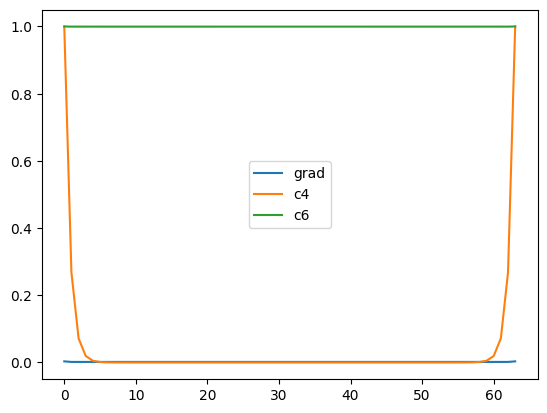

In [12]:
plt.plot(rel_rmse(v_grad, df_dy, axis=(0, 2)), label="grad")
plt.plot(rel_rmse(v_c4, df_dy, axis=(0, 2)), label="c4")
plt.plot(rel_rmse(v_c6, df_dy, axis=(0, 2)), label="c6")
plt.legend()
plt.show()

In [13]:
d = 2 * np.pi
res = 50
x = np.linspace(0, d, res, endpoint=True)
xf = np.cos(x)
xt = -np.sin(x)

In [14]:
vb_grad = np.gradient(xf, d / (res - 1), axis=0, edge_order=2)

In [15]:
rel_rmse(vb_grad, xt, axis=0)

np.float64(0.0027422786223957924)

In [16]:
rel_rmse(derive_compact(xf, 0, d / (res - 1)), xt, axis=0)

np.float64(1.5049176510135478e-06)

In [17]:
rel_rmse(derive_compact_6th(xf, 0, d / (res - 1)), xt, axis=0)

np.float64(0.009361731113346733)

In [34]:
def derive_6th(x, h):
    rhs = np.zeros_like(x)
    rhs[1:-1] = x[:-2] - x[2:]
    rhs *= 1.0 * h / (3.0)
    ab = np.zeros((5, x.shape[0]))
    a = 1 / 18  # 1/36
    b = 4 / 9  # 7/9
    c = -1  # 1/3
    ab[0, 3:] = a
    ab[1, 2:] = b
    ab[2, :] = c
    ab[3, :-2] = b
    ab[4, :-3] = a
    x_prime = solve_banded((2, 2), ab, rhs)
    return x_prime

In [35]:
rel_rmse(derive_6th(np.cos(x), d / (res - 1)), -np.sin(x), axis=0)

ValueError: invalid values for the number of lower and upper diagonals: l+u+1 (3) does not equal ab.shape[0] (5)

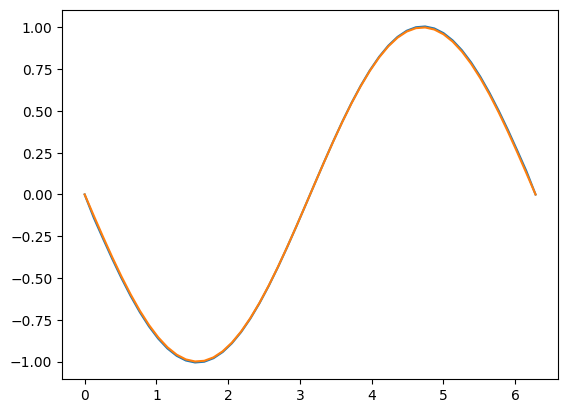

In [20]:
plt.plot(x, derive_6th(np.cos(x), d / (res - 1)))
plt.plot(x, -np.sin(x))
plt.show()

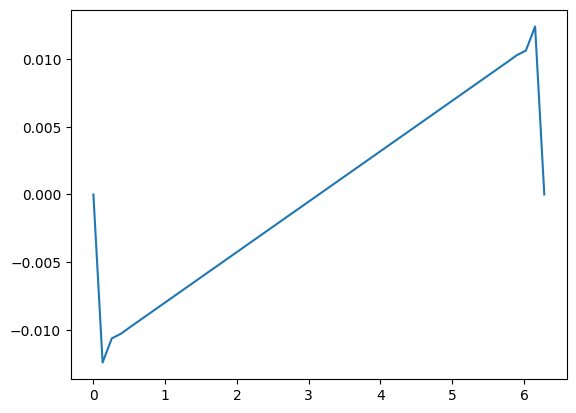

In [22]:
plt.plot(x, derive_6th(np.cos(x), d / (res - 1)) - -np.sin(x))
plt.show()

In [49]:
import numpy as np
from scipy.linalg import solve_banded


def derive_6th_in(x, h):
    n = x.shape[0]
    ab = np.zeros((3, n))
    rhs = np.zeros_like(x)

    ab[1, :] = 1
    ab[0, 1] = 2
    ab[0, 2] = 1 / 4
    ab[0, 3:n-1] = 1 / 3
    ab[0, n-1] = 1 / 4
    ab[2, 0] = 1 / 4
    ab[2, 1:n-2] = 1 / 3
    ab[2, n-2] = 2

    rhs[0] = (-5 / 2) * x[0] / h + 2 * x[1] / h + (1 / 2) * x[2] / h
    rhs[1] = (3 / 4) * (x[2] - x[0]) / h
    rhs[2:n-2] = (7 / 9) * (x[3:n-1] - x[1:n-3]) / h + (1 / 36) * (x[4:] - x[:-4]) / h
    rhs[n-2] = (3 / 4) * (x[n-1] - x[n-3]) / h
    rhs[n-1] = (5 / 2) * x[n-1] / h - 2 * x[n-2] / h - (1 / 2) * x[n-3] / h

    return solve_banded((1, 1), ab, rhs)


In [50]:
rel_rmse(derive_6th_in(np.cos(x), d / (res - 1)), -np.sin(x), axis=0)

np.float64(0.02597263559944235)

In [57]:
import numpy as np
from scipy.linalg import solve_banded

def derive_6th(x, h):
    # your current version (matrix confirmed correct)
    n = x.shape[0]
    ab = np.zeros((3, n)); rhs = np.zeros_like(x)
    ab[1, :] = 1
    ab[0, 1] = 2; ab[0, 2] = 1/4; ab[0, 3:n-1] = 1/3; ab[0, n-1] = 1/4
    ab[2, 0] = 1/4; ab[2, 1:n-2] = 1/3; ab[2, n-2] = 2
    rhs[0] = (-5/2)*x[0]/h + 2*x[1]/h + (1/2)*x[2]/h
    rhs[1] = (3/4)*(x[2]-x[0])/h
    rhs[2:n-2] = (7/9)*(x[3:n-1]-x[1:n-3])/h + (1/36)*(x[4:]-x[:-4])/h
    rhs[n-2] = (3/4)*(x[n-1]-x[n-3])/h
    rhs[n-1] = (5/2)*x[n-1]/h - 2*x[n-2]/h - (1/2)*x[n-3]/h
    return solve_banded((1,1), ab, rhs)

# Reversal test: the scheme's LEFT boundary is exact. Reverse the field,
# differentiate, reverse back. If the RIGHT boundary is the bug, this
# version will now be exact on the right end.
def derive_6th_rev(x, h):
    return derive_6th(x[::-1].copy(), h)[::-1]

N = 64
g = np.linspace(0, 2*np.pi, N); h = g[1]-g[0]
exact = np.cos(g)
e1 = np.abs(derive_6th(np.sin(g), h) - exact)
e2 = np.abs(derive_6th_rev(np.sin(g), h) - exact)
print("current  last 4 err :", np.round(e1[-4:], 4))
print("reversed last 4 err  :", np.round(e2[-4:], 4))
print("reversed first 4 err :", np.round(e2[:4], 4))


current  last 4 err : [0.032  0.0837 0.2192 0.4384]
reversed last 4 err  : [1.9111 1.9603 1.9901 2.    ]
reversed first 4 err : [2.4384 1.7709 2.0441 1.8792]
